# COVID-19 Global Intelligence

### Interactive Epidemiological Data Analysis & Visualization

**Objective**

This project analyzes global COVID-19 data to identify patterns in cases, deaths, recoveries, testing, and country-level risk.

The analysis follows a complete data analytics workflow:

**Raw Data → Data Understanding → Data Cleaning → Feature Engineering → Exploratory Analysis → Statistical Analysis → Insights**

The final insights will later be used to build an interactive Streamlit dashboard.

---

### Datasets

This project uses three datasets:

* **COVID Country Data** — country-level cases, deaths, recoveries, active cases, testing, population, and regional information.
* **COVID Time-Series Data** — date-wise confirmed cases, deaths, recoveries, active cases, and new cases.
* **COVID Death Conditions** — reported conditions associated with COVID-19 deaths.

### Tools

* Python
* Pandas
* NumPy
* Matplotlib
* Plotly
* Seaborn
* WordCloud

### Project Questions

1. Which countries experienced the highest COVID-19 case burden?
2. Which countries had the highest mortality and recovery rates?
3. How did COVID-19 cases change over time?
4. Is testing volume associated with reported cases?
5. How did the pandemic vary across regions?
6. Which countries show higher relative risk based on our engineered risk score?


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
covid_df = pd.read_csv("../data/raw/covid.csv")
covid_grouped_df = pd.read_csv("../data/raw/covid_grouped.csv")
covid_death_df = pd.read_csv("../data/raw/coviddeath.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print("Country-level dataset:", covid_df.shape)
print("Time-series dataset:", covid_grouped_df.shape)
print("Death-condition dataset:", covid_death_df.shape)

Country-level dataset: (209, 17)
Time-series dataset: (35156, 11)
Death-condition dataset: (12260, 10)


## 1. Data Understanding

Before cleaning the datasets, we first inspect their structure, size, columns, data types, missing values, and statistical characteristics.

The purpose of this stage is to understand the quality and structure of the raw data before making any preprocessing decisions.


In [4]:
# Preview the country-level dataset

covid_df.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region,iso_alpha
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas,USA
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas,BRA
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia,IND
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe,RUS
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa,ZAF


In [5]:
# Preview the time-series dataset

covid_grouped_df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,iso_alpha
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,AFG
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe,ALB
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa,DZA
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe,AND
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa,AGO


In [6]:
# Preview the death-condition dataset

covid_death_df.head()

,Data as of,Start Week,End Week,State,Condition Group,Condition,ICD10_codes,Age Group,Number of COVID-19 Deaths,Flag
0,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,0-24,122.0,NaN
1,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,25-34,596.0,NaN
2,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,35-44,1521.0,NaN
3,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,45-54,4186.0,NaN
4,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,55-64,10014.0,NaN


In [7]:
print("Country-level dataset")
print("Rows:", covid_df.shape[0])
print("Columns:", covid_df.shape[1])

print("\nTime-series dataset")
print("Rows:", covid_grouped_df.shape[0])
print("Columns:", covid_grouped_df.shape[1])

print("\nDeath-condition dataset")
print("Rows:", covid_death_df.shape[0])
print("Columns:", covid_death_df.shape[1])

Country-level dataset
Rows: 209
Columns: 17

Time-series dataset
Rows: 35156
Columns: 11

Death-condition dataset
Rows: 12260
Columns: 10


In [8]:
print("Country-level columns:")
print(covid_df.columns.tolist())

print("\nTime-series columns:")
print(covid_grouped_df.columns.tolist())

print("\nDeath-condition columns:")
print(covid_death_df.columns.tolist())

Country-level columns:
['Country/Region', 'Continent', 'Population', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop', 'WHO Region', 'iso_alpha']

Time-series columns:
['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'WHO Region', 'iso_alpha']

Death-condition columns:
['Data as of', 'Start Week', 'End Week', 'State', 'Condition Group', 'Condition', 'ICD10_codes', 'Age Group', 'Number of COVID-19 Deaths', 'Flag']


In [9]:
covid_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country/Region    209 non-null    str    
 1   Continent         208 non-null    str    
 2   Population        208 non-null    float64
 3   TotalCases        209 non-null    int64  
 4   NewCases          4 non-null      float64
 5   TotalDeaths       188 non-null    float64
 6   NewDeaths         3 non-null      float64
 7   TotalRecovered    205 non-null    float64
 8   NewRecovered      3 non-null      float64
 9   ActiveCases       205 non-null    float64
 10  Serious,Critical  122 non-null    float64
 11  Tot Cases/1M pop  208 non-null    float64
 12  Deaths/1M pop     187 non-null    float64
 13  TotalTests        191 non-null    float64
 14  Tests/1M pop      191 non-null    float64
 15  WHO Region        184 non-null    str    
 16  iso_alpha         209 non-null    str    
dtypes: float

In [10]:
covid_grouped_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Date            35156 non-null  str  
 1   Country/Region  35156 non-null  str  
 2   Confirmed       35156 non-null  int64
 3   Deaths          35156 non-null  int64
 4   Recovered       35156 non-null  int64
 5   Active          35156 non-null  int64
 6   New cases       35156 non-null  int64
 7   New deaths      35156 non-null  int64
 8   New recovered   35156 non-null  int64
 9   WHO Region      35156 non-null  str  
 10  iso_alpha       35156 non-null  str  
dtypes: int64(7), str(4)
memory usage: 4.0 MB


In [11]:
covid_death_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12260 entries, 0 to 12259
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Data as of                 12260 non-null  str    
 1   Start Week                 12260 non-null  str    
 2   End Week                   12260 non-null  str    
 3   State                      12260 non-null  str    
 4   Condition Group            12260 non-null  str    
 5   Condition                  12260 non-null  str    
 6   ICD10_codes                12260 non-null  str    
 7   Age Group                  12260 non-null  str    
 8   Number of COVID-19 Deaths  5354 non-null   float64
 9   Flag                       6906 non-null   str    
dtypes: float64(1), str(9)
memory usage: 2.3 MB


In [12]:
covid_df.isnull().sum()

Country/Region        0
Continent             1
Population            1
TotalCases            0
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
ActiveCases           4
Serious,Critical     87
Tot Cases/1M pop      1
Deaths/1M pop        22
TotalTests           18
Tests/1M pop         18
WHO Region           25
iso_alpha             0
dtype: int64

In [13]:
covid_grouped_df.isnull().sum()

Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region        0
iso_alpha         0
dtype: int64

In [14]:
covid_death_df.isnull().sum()

Data as of                      0
Start Week                      0
End Week                        0
State                           0
Condition Group                 0
Condition                       0
ICD10_codes                     0
Age Group                       0
Number of COVID-19 Deaths    6906
Flag                         5354
dtype: int64

In [15]:
missing_data = pd.DataFrame({
    "Missing Values": covid_df.isnull().sum(),
    "Missing Percentage": (covid_df.isnull().sum() / len(covid_df)) * 100
})

missing_data = missing_data.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_data

,Missing Values,Missing Percentage
NewRecovered,206,98.564593
NewDeaths,206,98.564593
NewCases,205,98.086124
"Serious,Critical",87,41.626794
WHO Region,25,11.961722
Deaths/1M pop,22,10.526316
TotalDeaths,21,10.047847
Tests/1M pop,18,8.612440
TotalTests,18,8.612440
TotalRecovered,4,1.913876


In [16]:
print("Duplicate rows:", covid_df.duplicated().sum())

Duplicate rows: 0


In [17]:
print("Time-series duplicates:", covid_grouped_df.duplicated().sum())
print("Death-condition duplicates:", covid_death_df.duplicated().sum())

Time-series duplicates: 0


Death-condition duplicates: 0


In [18]:
summary = covid_df.describe().T
summary.style.format("{:,.2f}")

,count,mean,std,min,25%,50%,75%,max
Population,208.00,"30,415,486.97","104,766,099.48",801.00,"966,314.00","7,041,972.50","25,756,135.50","1,381,344,997.00"
TotalCases,209.00,"91,718.50","432,586.68",10.00,712.00,"4,491.00","36,896.00","5,032,179.00"
NewCases,4.00,"1,980.50","3,129.61",20.00,27.50,656.00,"2,609.00","6,590.00"
TotalDeaths,188.00,"3,792.59","15,487.18",1.00,22.00,113.00,786.00,"162,804.00"
NewDeaths,3.00,300.00,451.20,1.00,40.50,80.00,449.50,819.00
TotalRecovered,205.00,"58,878.98","256,698.41",7.00,334.00,"2,178.00","20,553.00","2,576,668.00"
NewRecovered,3.00,"1,706.00","2,154.78",42.00,489.00,936.00,"2,538.00","4,140.00"
ActiveCases,205.00,"27,664.33","174,632.74",0.00,86.00,899.00,"7,124.00","2,292,707.00"
"Serious,Critical",122.00,534.39,"2,047.52",1.00,3.25,27.50,160.25,"18,296.00"
Tot Cases/1M pop,208.00,"3,196.02","5,191.99",3.00,282.00,"1,015.00","3,841.75","39,922.00"


In [19]:
data_quality = pd.DataFrame({
    "Data Type": covid_df.dtypes,
    "Missing Values": covid_df.isnull().sum(),
    "Missing %": (covid_df.isnull().sum() / len(covid_df) * 100).round(2),
    "Unique Values": covid_df.nunique()
})

data_quality

,Data Type,Missing Values,Missing %,Unique Values
Country/Region,str,0,0.00,209
Continent,str,1,0.48,6
Population,float64,1,0.48,208
TotalCases,int64,0,0.00,206
NewCases,float64,205,98.09,4
TotalDeaths,float64,21,10.05,150
NewDeaths,float64,206,98.56,3
TotalRecovered,float64,4,1.91,201
NewRecovered,float64,206,98.56,3
ActiveCases,float64,4,1.91,180


## 2. Data Cleaning Strategy

The data-quality assessment shows that the dataset contains several columns with substantial missing values.

Rather than removing all rows containing missing values, each column will be evaluated based on its analytical importance and the amount of missing data.

### Cleaning decisions

* `NewCases`, `NewDeaths`, and `NewRecovered` will be removed because more than 98% of their values are missing.
* `Country/Region` will be retained because it contains no missing values and uniquely identifies each country/region.
* `TotalCases` will be retained because it has complete data.
* `TotalDeaths`, `TotalRecovered`, and `ActiveCases` will be retained because they are important analytical variables. Their missing values will be handled carefully.
* `Population` and `Continent` contain only one missing value each and will be investigated before deciding how to handle them.
* `Serious,Critical` has a relatively high percentage of missing values, so it will be treated as a secondary variable rather than a core metric.
* Per-million indicators will be retained because they allow more meaningful comparisons between countries with different population sizes.

The goal is to preserve as much useful information as possible while avoiding unnecessary data loss.


In [20]:
# Find rows with missing Population or Continent

covid_df[
    covid_df["Population"].isnull() |
    covid_df["Continent"].isnull()
][["Country/Region", "Continent", "Population"]]

,Country/Region,Continent,Population
156,Diamond Princess,NaN,NaN


In [21]:
# Inspect missing values in important analytical columns

covid_df[
    covid_df["TotalDeaths"].isnull() |
    covid_df["TotalRecovered"].isnull() |
    covid_df["ActiveCases"].isnull()
][[
    "Country/Region",
    "TotalCases",
    "TotalDeaths",
    "TotalRecovered",
    "ActiveCases"
]]

,Country/Region,TotalCases,TotalDeaths,TotalRecovered,ActiveCases
9,Spain,354530,28500.0,NaN,NaN
11,UK,308134,46413.0,NaN,NaN
29,Sweden,81967,5766.0,NaN,NaN
40,Netherlands,56982,6153.0,NaN,NaN
168,Mongolia,293,NaN,260.0,33.0
169,Eritrea,282,NaN,225.0,57.0
172,Faeroe Islands,266,NaN,192.0,74.0
174,Cambodia,243,NaN,210.0,33.0
177,Gibraltar,190,NaN,184.0,6.0
184,Seychelles,126,NaN,124.0,2.0


In [22]:
covid_df["Serious,Critical"].describe()

count      122.000000
mean       534.393443
std       2047.518613
min          1.000000
25%          3.250000
50%         27.500000
75%        160.250000
max      18296.000000
Name: Serious,Critical, dtype: float64

In [23]:
covid_df[
    covid_df["Serious,Critical"].notna()
]["Serious,Critical"].head(20)

0     18296.0
1      8318.0
2      8944.0
3      2300.0
4       539.0
5      3987.0
6      1426.0
7      1358.0
8      1493.0
9       617.0
10     4156.0
11       73.0
12     1915.0
13      809.0
15       42.0
16      580.0
17     1150.0
18      236.0
19      384.0
20      517.0
Name: Serious,Critical, dtype: float64

## 3. Data Cleaning

The raw datasets are preserved without modification. A separate working copy is created for preprocessing.

The cleaning process focuses on removing highly incomplete columns, standardizing column names, and preserving useful country-level records wherever possible.


In [24]:
# Create a working copy of the raw country-level dataset

covid_clean = covid_df.copy()

print("Original shape:", covid_clean.shape)

Original shape: (209, 17)


In [25]:
# Remove columns with extremely high missing values

columns_to_drop = [
    "NewCases",
    "NewDeaths",
    "NewRecovered"
]

covid_clean = covid_clean.drop(columns=columns_to_drop)

print("Shape after removing highly incomplete columns:", covid_clean.shape)

Shape after removing highly incomplete columns: (209, 14)


In [26]:
# Rename columns to make them easier to work with

covid_clean = covid_clean.rename(columns={
    "Country/Region": "Country",
    "Serious,Critical": "Serious_Critical",
    "Tot Cases/1M pop": "Cases_per_1M",
    "Deaths/1M pop": "Deaths_per_1M",
    "Tests/1M pop": "Tests_per_1M"
})

covid_clean.columns

Index(['Country', 'Continent', 'Population', 'TotalCases', 'TotalDeaths',
       'TotalRecovered', 'ActiveCases', 'Serious_Critical', 'Cases_per_1M',
       'Deaths_per_1M', 'TotalTests', 'Tests_per_1M', 'WHO Region',
       'iso_alpha'],
      dtype='str')

In [27]:
# Inspect the cleaned dataset

covid_clean.head()

,Country,Continent,Population,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,Serious_Critical,Cases_per_1M,Deaths_per_1M,TotalTests,Tests_per_1M,WHO Region,iso_alpha
0,USA,North America,3.311981e+08,5032179,162804.0,2576668.0,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas,USA
1,Brazil,South America,2.127107e+08,2917562,98644.0,2047660.0,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas,BRA
2,India,Asia,1.381345e+09,2025409,41638.0,1377384.0,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia,IND
3,Russia,Europe,1.459409e+08,871894,14606.0,676357.0,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe,RUS
4,South Africa,Africa,5.938157e+07,538184,9604.0,387316.0,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa,ZAF


In [28]:
print("Rows:", covid_clean.shape[0])
print("Columns:", covid_clean.shape[1])

Rows: 209
Columns: 14


In [29]:
covid_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           209 non-null    str    
 1   Continent         208 non-null    str    
 2   Population        208 non-null    float64
 3   TotalCases        209 non-null    int64  
 4   TotalDeaths       188 non-null    float64
 5   TotalRecovered    205 non-null    float64
 6   ActiveCases       205 non-null    float64
 7   Serious_Critical  122 non-null    float64
 8   Cases_per_1M      208 non-null    float64
 9   Deaths_per_1M     187 non-null    float64
 10  TotalTests        191 non-null    float64
 11  Tests_per_1M      191 non-null    float64
 12  WHO Region        184 non-null    str    
 13  iso_alpha         209 non-null    str    
dtypes: float64(9), int64(1), str(4)
memory usage: 28.5 KB


In [30]:
# Check remaining missing values

clean_missing = pd.DataFrame({
    "Missing Values": covid_clean.isnull().sum(),
    "Missing %": (
        covid_clean.isnull().sum() / len(covid_clean) * 100
    ).round(2)
})

clean_missing = clean_missing[
    clean_missing["Missing Values"] > 0
].sort_values(
    "Missing %",
    ascending=False
)

clean_missing

,Missing Values,Missing %
Serious_Critical,87,41.63
WHO Region,25,11.96
Deaths_per_1M,22,10.53
TotalDeaths,21,10.05
TotalTests,18,8.61
Tests_per_1M,18,8.61
TotalRecovered,4,1.91
ActiveCases,4,1.91
Continent,1,0.48
Population,1,0.48


In [31]:
# Check for duplicate rows after cleaning

print(
    "Duplicate rows after cleaning:",
    covid_clean.duplicated().sum()
)

Duplicate rows after cleaning: 0


In [32]:
# Check for negative values in important numerical columns

numeric_columns = [
    "Population",
    "TotalCases",
    "TotalDeaths",
    "TotalRecovered",
    "ActiveCases",
    "TotalTests"
]

negative_values = (covid_clean[numeric_columns] < 0).sum()

negative_values

Population        0
TotalCases        0
TotalDeaths       0
TotalRecovered    0
ActiveCases       0
TotalTests        0
dtype: int64

## 4. Feature Engineering

Feature engineering transforms the cleaned dataset into more meaningful analytical variables.

Instead of comparing countries only using absolute case and death counts, we will calculate normalized indicators such as mortality rate, recovery rate, active case rate, cases per million, and deaths per million.

We will also create a composite **COVID Impact Score** to compare countries using multiple epidemiological indicators.

> **Note:** The COVID Impact Score is an analytical index created for this project. It is not a medical or clinical risk prediction model.


In [33]:
# Calculate the percentage of confirmed cases that resulted in death

covid_clean["Mortality_Rate"] = (
    covid_clean["TotalDeaths"] / covid_clean["TotalCases"]
) * 100

covid_clean[["Country", "TotalCases", "TotalDeaths", "Mortality_Rate"]].head()

,Country,TotalCases,TotalDeaths,Mortality_Rate
0,USA,5032179,162804.0,3.235259
1,Brazil,2917562,98644.0,3.381042
2,India,2025409,41638.0,2.055782
3,Russia,871894,14606.0,1.675204
4,South Africa,538184,9604.0,1.784520


In [34]:
# Calculate the percentage of confirmed cases that were recovered

covid_clean["Recovery_Rate"] = (
    covid_clean["TotalRecovered"] / covid_clean["TotalCases"]
) * 100

covid_clean[[
    "Country",
    "TotalCases",
    "TotalRecovered",
    "Recovery_Rate"
]].head()

,Country,TotalCases,TotalRecovered,Recovery_Rate
0,USA,5032179,2576668.0,51.203822
1,Brazil,2917562,2047660.0,70.183941
2,India,2025409,1377384.0,68.005228
3,Russia,871894,676357.0,77.573306
4,South Africa,538184,387316.0,71.967208


In [35]:
# Calculate the percentage of confirmed cases that are currently active

covid_clean["Active_Case_Rate"] = (
    covid_clean["ActiveCases"] / covid_clean["TotalCases"]
) * 100

covid_clean[[
    "Country",
    "TotalCases",
    "ActiveCases",
    "Active_Case_Rate"
]].head()

,Country,TotalCases,ActiveCases,Active_Case_Rate
0,USA,5032179,2292707.0,45.560919
1,Brazil,2917562,771258.0,26.435017
2,India,2025409,606387.0,29.938990
3,Russia,871894,180931.0,20.751490
4,South Africa,538184,141264.0,26.248272


In [36]:
# Calculate confirmed cases per million population

covid_clean["Calculated_Cases_per_1M"] = (
    covid_clean["TotalCases"] / covid_clean["Population"]
) * 1_000_000

covid_clean[[
    "Country",
    "Population",
    "TotalCases",
    "Calculated_Cases_per_1M"
]].head()

,Country,Population,TotalCases,Calculated_Cases_per_1M
0,USA,3.311981e+08,5032179,15193.862961
1,Brazil,2.127107e+08,2917562,13716.104125
2,India,1.381345e+09,2025409,1466.258613
3,Russia,1.459409e+08,871894,5974.294092
4,South Africa,5.938157e+07,538184,9063.149328


In [37]:
# Calculate deaths per million population

covid_clean["Calculated_Deaths_per_1M"] = (
    covid_clean["TotalDeaths"] / covid_clean["Population"]
) * 1_000_000

covid_clean[[
    "Country",
    "TotalDeaths",
    "Calculated_Deaths_per_1M"
]].head()

,Country,TotalDeaths,Calculated_Deaths_per_1M
0,USA,162804.0,491.560746
1,Brazil,98644.0,463.747257
2,India,41638.0,30.143085
3,Russia,14606.0,100.081592
4,South Africa,9604.0,161.733694


In [38]:
# Calculate tests conducted per million population

covid_clean["Calculated_Tests_per_1M"] = (
    covid_clean["TotalTests"] / covid_clean["Population"]
) * 1_000_000

covid_clean[[
    "Country",
    "Population",
    "TotalTests",
    "Calculated_Tests_per_1M"
]].head()

,Country,Population,TotalTests,Calculated_Tests_per_1M
0,USA,3.311981e+08,63139605.0,190639.980365
1,Brazil,2.127107e+08,13206188.0,62085.210084
2,India,1.381345e+09,22149351.0,16034.626432
3,Russia,1.459409e+08,29716907.0,203622.850846
4,South Africa,5.938157e+07,3149807.0,53043.515222


In [39]:
# Create percentile-based scores for each major indicator

covid_clean["Case_Burden_Score"] = (
    covid_clean["Calculated_Cases_per_1M"]
    .rank(pct=True) * 100
)

covid_clean["Death_Burden_Score"] = (
    covid_clean["Calculated_Deaths_per_1M"]
    .rank(pct=True) * 100
)

covid_clean["Active_Burden_Score"] = (
    covid_clean["Active_Case_Rate"]
    .rank(pct=True) * 100
)

In [40]:
# Combine the three percentile scores

covid_clean["COVID_Impact_Score"] = (
    covid_clean["Case_Burden_Score"]
    + covid_clean["Death_Burden_Score"]
    + covid_clean["Active_Burden_Score"]
) / 3

covid_clean["COVID_Impact_Score"] = (
    covid_clean["COVID_Impact_Score"].round(2)
)

covid_clean[[
    "Country",
    "Case_Burden_Score",
    "Death_Burden_Score",
    "Active_Burden_Score",
    "COVID_Impact_Score"
]].head(10)

,Country,Case_Burden_Score,Death_Burden_Score,Active_Burden_Score,COVID_Impact_Score
0,USA,96.153846,95.187166,80.975610,90.77
1,Brazil,94.711538,94.117647,58.048780,82.29
2,India,56.250000,51.871658,66.829268,58.32
3,Russia,85.576923,75.401070,50.731707,70.57
4,South Africa,91.826923,82.887701,57.073171,77.26
5,Mexico,73.557692,93.582888,53.170732,73.44
6,Peru,95.192308,97.860963,60.975610,84.68
7,Chile,98.076923,95.721925,15.121951,69.64
8,Colombia,87.500000,87.165775,76.585366,83.75
9,Spain,89.423077,97.326203,NaN,NaN


In [41]:
# Classify countries based on their COVID Impact Score

def classify_impact(score):
    if pd.isna(score):
        return "Insufficient Data"
    elif score >= 75:
        return "Critical"
    elif score >= 50:
        return "High"
    elif score >= 25:
        return "Moderate"
    else:
        return "Low"


covid_clean["Impact_Category"] = (
    covid_clean["COVID_Impact_Score"]
    .apply(classify_impact)
)

covid_clean[[
    "Country",
    "COVID_Impact_Score",
    "Impact_Category"
]].head(15)

,Country,COVID_Impact_Score,Impact_Category
0,USA,90.77,Critical
1,Brazil,82.29,Critical
2,India,58.32,High
3,Russia,70.57,High
4,South Africa,77.26,Critical
5,Mexico,73.44,High
6,Peru,84.68,Critical
7,Chile,69.64,High
8,Colombia,83.75,Critical
9,Spain,NaN,Insufficient Data


In [42]:
impact_distribution = (
    covid_clean["Impact_Category"]
    .value_counts()
)

impact_distribution

Impact_Category
High                 80
Moderate             62
Insufficient Data    26
Critical             22
Low                  19
Name: count, dtype: int64

In [43]:
# Keep only countries with a calculated impact score

impact_distribution_valid = (
    covid_clean[
        covid_clean["Impact_Category"] != "Insufficient Data"
    ]["Impact_Category"]
    .value_counts()
    .rename_axis("Impact_Category")
    .reset_index(name="Number_of_Countries")
)


impact_order = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

impact_chart = (
    impact_distribution_valid[
        impact_distribution_valid["Impact_Category"].isin(impact_order)
    ]
    .copy()
)

impact_chart["Impact_Category"] = pd.Categorical(
    impact_chart["Impact_Category"],
    categories=impact_order,
    ordered=True
)

impact_chart = impact_chart.sort_values("Impact_Category")

fig = px.bar(
    impact_chart,
    x="Number_of_Countries",
    y="Impact_Category",
    orientation="h",
    text="Number_of_Countries",
    color="Number_of_Countries",
    color_continuous_scale="Turbo",
    title="<b>COVID-19 Impact Profile</b>",
    labels={
        "Number_of_Countries": "Number of Countries",
        "Impact_Category": "Impact Category"
    },
    height=520
)

fig.update_traces(
    textposition="outside",
    textfont=dict(size=14),
    marker=dict(
        line=dict(width=1, color="white")
    ),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Countries: %{x}<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=24)
    ),
    xaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    yaxis=dict(
        title="",
        categoryorder="array",
        categoryarray=impact_order
    ),
    coloraxis_colorbar=dict(
        title="Country Count"
    ),
    margin=dict(l=80, r=80, t=90, b=60)
)

fig.show()

### Insight

The engineered COVID Impact Score classifies countries into four relative impact levels: Low, Moderate, High, and Critical.

In the current dataset, the **High-impact category contains the largest number of countries**, followed by the Moderate category. A smaller group falls into the Critical category.

The classification is based on relative case burden, death burden, and active case rate. Therefore, the score should be interpreted as a **comparative analytical index within this dataset**, rather than as a clinical measure of disease severity.

Countries with insufficient information are retained in the dataset but excluded from the impact-distribution visualization to avoid treating missing data as an impact category.


## 5. Top Countries by COVID Impact

The next analysis identifies countries with the highest COVID Impact Score.

Rather than ranking countries only by confirmed cases, this comparison considers three dimensions simultaneously:

* Case burden per million population
* Death burden per million population
* Active case rate

This provides a more balanced comparison than using total cases alone.


In [44]:
top_impact_countries = (
    covid_clean[
        covid_clean["Impact_Category"] != "Insufficient Data"
    ][
        [
            "Country",
            "COVID_Impact_Score",
            "Case_Burden_Score",
            "Death_Burden_Score",
            "Active_Burden_Score",
            "Impact_Category"
        ]
    ]
    .sort_values(
        "COVID_Impact_Score",
        ascending=False
    )
    .head(10)
)

top_impact_countries

,Country,COVID_Impact_Score,Case_Burden_Score,Death_Burden_Score,Active_Burden_Score,Impact_Category
35,Belgium,92.25,86.057692,99.465241,91.219512,Critical
28,Bolivia,91.15,88.942308,90.374332,94.146341,Critical
0,USA,90.77,96.153846,95.187166,80.975610,Critical
34,Panama,86.95,97.596154,92.513369,70.731707,Critical
46,Honduras,86.06,78.846154,81.283422,98.048780,Critical
6,Peru,84.68,95.192308,97.860963,60.975610,Critical
179,Sint Maarten,84.15,74.519231,93.048128,84.878049,Critical
8,Colombia,83.75,87.500000,87.165775,76.585366,Critical
1,Brazil,82.29,94.711538,94.117647,58.048780,Critical
33,Dominican Republic,82.02,87.980769,78.074866,80.000000,Critical


In [104]:
# TOP 10 COUNTRIES BY COVID IMPACT SCORE

top_impact = (
    covid_clean
    .dropna(subset=["COVID_Impact_Score"])
    .sort_values("COVID_Impact_Score", ascending=False)
    .head(100)
    .sort_values("COVID_Impact_Score")
)

fig = px.bar(
    top_impact,
    x="COVID_Impact_Score",
    y="Country",
    orientation="h",
    color="COVID_Impact_Score",
    color_continuous_scale="Turbo",
    text="COVID_Impact_Score",
    hover_data={
        "COVID_Impact_Score": ":.2f",
        "Case_Burden_Score": ":.2f",
        "Death_Burden_Score": ":.2f",
        "Active_Burden_Score": ":.2f",
        "Impact_Category": True
    },
    title="<b>COVID-19 Impact Leaderboard</b>",
    labels={
        "COVID_Impact_Score": "Impact Score",
        "Country": "Country"
    },
    height=560
)

fig.update_traces(
    texttemplate="%{text:.1f}",
    textposition="outside",
    marker_line_width=1,
    marker_line_color="rgba(255,255,255,0.5)",
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Impact Score: %{x:.2f}<br>"
        "Category: %{customdata[4]}<br>"
        "Case Burden: %{customdata[0]:.2f}<br>"
        "Death Burden: %{customdata[1]:.2f}<br>"
        "Active Burden: %{customdata[2]:.2f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=25)
    ),
    xaxis=dict(
        title="COVID Impact Score",
        range=[0, 100],
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    yaxis=dict(
        title="",
        tickfont=dict(size=13)
    ),
    coloraxis_colorbar=dict(
        title="Impact"
    ),
    margin=dict(l=120, r=100, t=90, b=60)
)

fig.show()

### Insight

The highest COVID Impact Scores are concentrated among countries with relatively high combinations of case burden, death burden, and active case rate.

Belgium has the highest relative impact score in this dataset, followed by Bolivia and the United States.

These rankings should be interpreted as **relative comparisons within the available dataset**. A high score does not necessarily indicate the highest absolute number of cases or deaths; it reflects the combined relative position of a country across the three indicators used in our project.


## 6. Testing and Case Burden

### Question

Is there a relationship between the amount of COVID-19 testing performed and the reported case burden?

To make countries comparable despite differences in population size, we will compare:

* **Tests per million population**
* **Confirmed cases per million population**

Countries with missing population, testing, or case data will be excluded from this specific analysis.


In [46]:
testing_analysis = covid_clean[
    [
        "Country",
        "Calculated_Tests_per_1M",
        "Calculated_Cases_per_1M"
    ]
].dropna()

testing_analysis.head()

,Country,Calculated_Tests_per_1M,Calculated_Cases_per_1M
0,USA,190639.980365,15193.862961
1,Brazil,62085.210084,13716.104125
2,India,16034.626432,1466.258613
3,Russia,203622.850846,5974.294092
4,South Africa,53043.515222,9063.149328


In [47]:
correlation = testing_analysis[
    "Calculated_Tests_per_1M"
].corr(
    testing_analysis["Calculated_Cases_per_1M"]
)

print(
    f"Correlation between testing rate and case rate: "
    f"{correlation:.2f}"
)

Correlation between testing rate and case rate: 0.30


In [105]:
# TESTING INTENSITY VS COVID CASE BURDEN

testing_chart = testing_analysis.merge(
    covid_clean[
        [
            "Country",
            "COVID_Impact_Score",
            "Impact_Category",
            "Mortality_Rate"
        ]
    ],
    on="Country",
    how="left"
)

testing_chart = testing_chart.dropna(
    subset=[
        "Calculated_Tests_per_1M",
        "Calculated_Cases_per_1M",
        "COVID_Impact_Score"
    ]
)

fig = px.scatter(
    testing_chart,
    x="Calculated_Tests_per_1M",
    y="Calculated_Cases_per_1M",
    size="COVID_Impact_Score",
    color="COVID_Impact_Score",
    color_continuous_scale="Turbo",
    hover_name="Country",
    hover_data={
        "Calculated_Tests_per_1M": ":,.0f",
        "Calculated_Cases_per_1M": ":,.0f",
        "COVID_Impact_Score": ":.2f",
        "Mortality_Rate": ":.2f",
        "Impact_Category": True
    },
    size_max=45,
    opacity=0.78,
    log_x=True,
    log_y=True,
    title="<b>Testing Intensity vs. COVID-19 Case Burden</b>",
    labels={
        "Calculated_Tests_per_1M": "Tests per Million",
        "Calculated_Cases_per_1M": "Cases per Million",
        "COVID_Impact_Score": "Impact Score"
    },
    height=650
)

fig.update_traces(
    marker=dict(
        line=dict(
            width=1,
            color="rgba(255,255,255,0.7)"
        )
    )
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=25)
    ),
    xaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    coloraxis_colorbar=dict(
        title="Impact Score"
    ),
    margin=dict(l=80, r=80, t=100, b=70)
)

fig.show()

In [49]:
top_testing = (
    testing_analysis
    .sort_values(
        "Calculated_Tests_per_1M",
        ascending=False
    )
    .head(10)
)

top_testing

,Country,Calculated_Tests_per_1M,Calculated_Cases_per_1M
91,Luxembourg,995281.935459,11281.565415
185,Monaco,972981.920041,3183.091418
172,Faeroe Islands,880589.992226,5441.675873
177,Gibraltar,684565.152864,5639.655684
38,UAE,531470.007460,6245.658109
206,Falkland Islands,520492.977931,3725.995987
47,Bahrain,513690.703938,25130.239080
176,Cayman Islands,472780.327670,3085.200158
129,Iceland,438384.607500,5652.116615
180,Bermuda,423298.101327,2521.926302


In [50]:
top_case_rate = (
    testing_analysis
    .sort_values(
        "Calculated_Cases_per_1M",
        ascending=False
    )
    .head(10)
)

top_case_rate

,Country,Calculated_Tests_per_1M,Calculated_Cases_per_1M
24,Qatar,181992.695362,39921.575750
84,French Guiana,138323.563305,27145.648580
47,Bahrain,513690.703938,25130.239080
157,San Marino,178796.629147,20596.381637
7,Chile,92022.146175,19164.810228
34,Panama,55769.329565,16527.039892
36,Kuwait,122104.690158,16378.443168
30,Oman,60411.304525,15769.043964
0,USA,190639.980365,15193.862961
6,Peru,75521.108213,13793.451656


## 7. Case Burden vs. Mortality

### Analytical Question

How does population-normalized COVID-19 case burden relate to
population-normalized death burden across countries?

Bubble size represents population, while color represents the
engineered COVID Impact Score.

In [106]:
# CASE BURDEN VS MORTALITY

case_death_chart = covid_clean[
    [
        "Country",
        "Population",
        "Calculated_Cases_per_1M",
        "Calculated_Deaths_per_1M",
        "COVID_Impact_Score",
        "Impact_Category",
        "Mortality_Rate"
    ]
].copy()

case_death_chart = case_death_chart.dropna(
    subset=[
        "Calculated_Cases_per_1M",
        "Calculated_Deaths_per_1M",
        "COVID_Impact_Score"
    ]
)

# Remove zero/negative values because log scales require positive values
case_death_chart = case_death_chart[
    (case_death_chart["Calculated_Cases_per_1M"] > 0) &
    (case_death_chart["Calculated_Deaths_per_1M"] > 0)
]

fig = px.scatter(
    case_death_chart,
    x="Calculated_Cases_per_1M",
    y="Calculated_Deaths_per_1M",
    size="Population",
    color="COVID_Impact_Score",
    color_continuous_scale="Plasma",
    hover_name="Country",
    hover_data={
        "Population": ":,.0f",
        "Calculated_Cases_per_1M": ":,.0f",
        "Calculated_Deaths_per_1M": ":,.0f",
        "COVID_Impact_Score": ":.2f",
        "Mortality_Rate": ":.2f",
        "Impact_Category": True
    },
    size_max=55,
    opacity=0.78,
    log_x=True,
    log_y=True,
    title="<b>COVID-19 Case Burden vs. Mortality</b>",
    labels={
        "Calculated_Cases_per_1M": "Cases per Million",
        "Calculated_Deaths_per_1M": "Deaths per Million",
        "COVID_Impact_Score": "Impact Score",
        "Population": "Population"
    },
    height=680
)

fig.update_traces(
    marker=dict(
        line=dict(
            width=1,
            color="rgba(255,255,255,0.75)"
        )
    )
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=26)
    ),
    xaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    coloraxis_colorbar=dict(
        title="COVID<br>Impact"
    ),
    margin=dict(
        l=90,
        r=90,
        t=105,
        b=80
    )
)

fig.show()

## 8. Regional COVID-19 Intelligence

### Analytical Question

How does COVID-19 burden vary across geographical regions?

In [107]:
# REGIONAL COVID-19 INTELLIGENCE

regional_chart = (
    covid_clean
    .groupby("Continent", dropna=False)
    .agg(
        Countries=("Country", "count"),
        Population=("Population", "sum"),
        Total_Cases=("TotalCases", "sum"),
        Total_Deaths=("TotalDeaths", "sum"),
        Avg_Impact=("COVID_Impact_Score", "mean"),
        Avg_Cases_per_1M=("Calculated_Cases_per_1M", "mean"),
        Avg_Deaths_per_1M=("Calculated_Deaths_per_1M", "mean")
    )
    .reset_index()
)

regional_chart = regional_chart.dropna(
    subset=["Continent", "Avg_Impact"]
)

fig = px.scatter(
    regional_chart,
    x="Avg_Cases_per_1M",
    y="Avg_Deaths_per_1M",
    size="Population",
    color="Avg_Impact",
    text="Continent",
    color_continuous_scale="Turbo",
    hover_data={
        "Countries": True,
        "Population": ":,.0f",
        "Total_Cases": ":,.0f",
        "Total_Deaths": ":,.0f",
        "Avg_Impact": ":.2f",
        "Avg_Cases_per_1M": ":,.0f",
        "Avg_Deaths_per_1M": ":,.0f"
    },
    size_max=70,
    title="<b>Regional COVID-19 Burden Landscape</b>",
    labels={
        "Avg_Cases_per_1M": "Average Cases per Million",
        "Avg_Deaths_per_1M": "Average Deaths per Million",
        "Avg_Impact": "Average Impact Score"
    },
    height=620
)

fig.update_traces(
    textposition="top center",
    marker=dict(
        line=dict(
            width=1.5,
            color="rgba(255,255,255,0.7)"
        )
    )
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=25)
    ),
    xaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    coloraxis_colorbar=dict(
        title="Avg Impact"
    )
)

fig.show()

## 9. Global COVID-19 Timeline

### Analytical Question

How did the COVID-19 pandemic evolve globally over time?

This section analyzes cumulative cases, deaths, recoveries, active cases, and daily new cases to understand the temporal progression of the pandemic.

In [108]:
# PREPARE GLOBAL TIME-SERIES DATA

timeline_df = covid_grouped_df.copy()

# Convert Date to datetime
timeline_df["Date"] = pd.to_datetime(timeline_df["Date"])

# Sort chronologically
timeline_df = timeline_df.sort_values("Date")

timeline_df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,iso_alpha
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,AFG
120,2020-01-22,Netherlands,0,0,0,0,0,0,0,Europe,NLD
121,2020-01-22,New Zealand,0,0,0,0,0,0,0,Western Pacific,NZL
122,2020-01-22,Nicaragua,0,0,0,0,0,0,0,Americas,NIC
123,2020-01-22,Niger,0,0,0,0,0,0,0,Africa,NGA


In [109]:
# GLOBAL DAILY COVID-19 TOTALS

global_timeline = (
    timeline_df
    .groupby("Date")[
        [
            "Confirmed",
            "Deaths",
            "Recovered",
            "Active",
            "New cases",
            "New deaths",
            "New recovered"
        ]
    ]
    .sum()
    .reset_index()
)

global_timeline.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
0,2020-01-22,555,17,28,510,0,0,0
1,2020-01-23,654,18,30,606,99,1,2
2,2020-01-24,941,26,36,879,287,8,6
3,2020-01-25,1434,42,39,1353,493,16,3
4,2020-01-26,2118,56,52,2010,684,14,13


In [110]:
# GLOBAL COVID-19 CASE EVOLUTION

fig = px.area(
    global_timeline,
    x="Date",
    y="Confirmed",
    title="<b>Global COVID-19 Case Evolution</b>",
    labels={
        "Date": "Date",
        "Confirmed": "Confirmed Cases"
    }
)

fig.update_traces(
    line=dict(
        width=3
    ),
    hovertemplate=(
        "<b>Date:</b> %{x|%d %b %Y}<br>"
        "<b>Confirmed Cases:</b> %{y:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=26)
    ),
    xaxis=dict(
        rangeslider=dict(
            visible=True
        ),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    yaxis=dict(
        title="Confirmed Cases",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    hovermode="x unified",
    height=600,
    margin=dict(
        l=80,
        r=60,
        t=100,
        b=80
    )
)

fig.show()

In [111]:
# GLOBAL COVID-19 DEATH EVOLUTION

fig = px.area(
    global_timeline,
    x="Date",
    y="Deaths",
    title="<b>Global COVID-19 Death Evolution</b>",
    labels={
        "Date": "Date",
        "Deaths": "Total Deaths"
    }
)

fig.update_traces(
    line=dict(width=3),
    hovertemplate=(
        "<b>Date:</b> %{x|%d %b %Y}<br>"
        "<b>Total Deaths:</b> %{y:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=26)
    ),
    xaxis=dict(
        rangeslider=dict(visible=True),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    yaxis=dict(
        title="Deaths",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    hovermode="x unified",
    height=600
)

fig.show()

In [112]:
# GLOBAL ACTIVE VS RECOVERED CASES

comparison_df = global_timeline[
    ["Date", "Active", "Recovered"]
].melt(
    id_vars="Date",
    var_name="Metric",
    value_name="Cases"
)

fig = px.area(
    comparison_df,
    x="Date",
    y="Cases",
    color="Metric",
    title="<b>Global Active vs. Recovered Cases</b>",
    labels={
        "Date": "Date",
        "Cases": "Number of Cases",
        "Metric": "Metric"
    },
    color_discrete_map={
        "Active": "#F59E0B",
        "Recovered": "#22C55E"
    }
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=26)
    ),
    hovermode="x unified",
    xaxis=dict(
        rangeslider=dict(visible=True),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    height=600
)

fig.show()

In [113]:
# GLOBAL DAILY NEW CASES

fig = px.bar(
    global_timeline,
    x="Date",
    y="New cases",
    title="<b>Global Daily COVID-19 Cases</b>",
    labels={
        "Date": "Date",
        "New cases": "New Cases"
    },
    color="New cases",
    color_continuous_scale="Turbo"
)

fig.update_traces(
    hovertemplate=(
        "<b>Date:</b> %{x|%d %b %Y}<br>"
        "<b>New Cases:</b> %{y:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=26)
    ),
    xaxis=dict(
        rangeslider=dict(visible=True),
        showgrid=False
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),
    coloraxis_colorbar=dict(
        title="New Cases"
    ),
    height=600
)

fig.show()

### Key Insight

The global timeline provides a temporal view of the COVID-19 pandemic that complements the country-level and regional analyses.

Cumulative confirmed cases and deaths illustrate the overall growth of the pandemic, while daily new cases reveal changes in the pace of reported infections.

The active-versus-recovered comparison provides additional context about how the reported case burden evolved over time.

These trends describe patterns within the available dataset and should not be interpreted as causal explanations for changes in disease transmission.

## 10. Global COVID-19 Spread — Interactive World Map

### Analytical Question

How did the reported COVID-19 case burden spread and evolve across countries over time?

An animated choropleth map is used to combine geography, case burden, and time into a single interactive visualization.

In [114]:
# PREPARE DATA FOR GLOBAL COVID-19 MAP

map_df = timeline_df.copy()

# Make sure dates are datetime
map_df["Date"] = pd.to_datetime(map_df["Date"])

# Remove records without ISO country codes
map_df = map_df.dropna(subset=["iso_alpha"])

# Sort by date
map_df = map_df.sort_values("Date")

print(f"Map records: {len(map_df):,}")
print(f"Countries represented: {map_df['iso_alpha'].nunique()}")
print(
    f"Date range: "
    f"{map_df['Date'].min().date()} → "
    f"{map_df['Date'].max().date()}"
)

Map records: 35,156
Countries represented: 179
Date range: 2020-01-22 → 2020-07-27


In [115]:
# ANIMATED GLOBAL COVID-19 CASE SPREAD

fig = px.choropleth(
    map_df,
    locations="iso_alpha",
    color="Confirmed",
    hover_name="Country/Region",
    hover_data={
        "Confirmed": ":,.0f",
        "Deaths": ":,.0f",
        "Recovered": ":,.0f",
        "Active": ":,.0f",
        "iso_alpha": False
    },
    color_continuous_scale="Turbo",
    animation_frame="Date",
    projection="natural earth",
    title="<b>Global COVID-19 Case Spread Over Time</b>",
    labels={
        "Confirmed": "Confirmed Cases"
    }
)

fig.update_layout(
    template="plotly_dark",
    title=dict(
        x=0.5,
        font=dict(size=26)
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="rgba(255,255,255,0.35)",
        projection_type="natural earth"
    ),
    coloraxis_colorbar=dict(
        title="Confirmed<br>Cases"
    ),
    height=720,
    margin=dict(
        l=20,
        r=20,
        t=100,
        b=30
    )
)

fig.show()

### Key Insight

The animated geographic view reveals how reported COVID-19 case burden evolved across countries over the observation period.

The combination of geographic position, color intensity, and time makes it possible to observe changes that are difficult to identify from a static country-level table.

The visualization represents reported case counts in the source dataset and should therefore be interpreted within the dataset's reporting and coverage limitations.

## 11. Regional COVID-19 Evolution

### Analytical Question

How did reported COVID-19 cases evolve across different WHO regions over time?

This analysis aggregates country-level records into regional totals to compare the progression of reported cases across major geographic regions.

In [116]:
# PREPARE REGIONAL TIME-SERIES DATA

regional_timeline = (
    timeline_df
    .groupby(["Date", "WHO Region"])[
        [
            "Confirmed",
            "Deaths",
            "Recovered",
            "Active"
        ]
    ]
    .sum()
    .reset_index()
)

regional_timeline["Date"] = pd.to_datetime(
    regional_timeline["Date"]
)

regional_timeline = regional_timeline.sort_values(
    ["Date", "WHO Region"]
)

regional_timeline.head()

,Date,WHO Region,Confirmed,Deaths,Recovered,Active
0,2020-01-22,Africa,0,0,0,0
1,2020-01-22,Americas,1,0,0,1
2,2020-01-22,Eastern Mediterranean,0,0,0,0
3,2020-01-22,Europe,0,0,0,0
4,2020-01-22,South-East Asia,2,0,0,2


In [117]:
# REGIONAL COVID-19 CASE EVOLUTION

fig = px.area(
    regional_timeline,
    x="Date",
    y="Confirmed",
    color="WHO Region",
    title="<b>COVID-19 Confirmed Cases by WHO Region</b>",
    labels={
        "Date": "Date",
        "Confirmed": "Confirmed Cases",
        "WHO Region": "WHO Region"
    }
)

fig.update_traces(
    hovertemplate=(
        "<b>Region:</b> %{fullData.name}<br>"
        "<b>Date:</b> %{x|%d %b %Y}<br>"
        "<b>Confirmed Cases:</b> %{y:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_dark",

    title=dict(
        x=0.5,
        font=dict(size=26)
    ),

    xaxis=dict(
        rangeslider=dict(
            visible=True
        ),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),

    yaxis=dict(
        title="Confirmed Cases",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),

    hovermode="x unified",

    height=650,

    margin=dict(
        l=80,
        r=40,
        t=100,
        b=80
    )
)

fig.show()

In [118]:
# NORMALIZED REGIONAL COVID-19 EVOLUTION

regional_normalized = regional_timeline.copy()

regional_normalized["Peak Confirmed"] = (
    regional_normalized
    .groupby("WHO Region")["Confirmed"]
    .transform("max")
)

regional_normalized["Peak %"] = (
    regional_normalized["Confirmed"]
    / regional_normalized["Peak Confirmed"]
    * 100
)

regional_normalized["Peak %"] = (
    regional_normalized["Peak %"]
    .round(2)
)

regional_normalized.head()

,Date,WHO Region,Confirmed,Deaths,Recovered,Active,Peak Confirmed,Peak %
0,2020-01-22,Africa,0,0,0,0,723207,0.0
1,2020-01-22,Americas,1,0,0,1,8839286,0.0
2,2020-01-22,Eastern Mediterranean,0,0,0,0,1490744,0.0
3,2020-01-22,Europe,0,0,0,0,3299523,0.0
4,2020-01-22,South-East Asia,2,0,0,2,1835297,0.0


In [119]:
# REGIONAL PROGRESSION RELATIVE TO PEAK

fig = px.line(
    regional_normalized,
    x="Date",
    y="Peak %",
    color="WHO Region",
    title="<b>Regional COVID-19 Progression Relative to Peak</b>",
    labels={
        "Date": "Date",
        "Peak %": "Cases Relative to Regional Peak (%)",
        "WHO Region": "WHO Region"
    }
)

fig.update_traces(
    line=dict(width=3)
)

fig.update_layout(
    template="plotly_dark",

    title=dict(
        x=0.5,
        font=dict(size=26)
    ),

    yaxis=dict(
        range=[0, 105],
        ticksuffix="%",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),

    xaxis=dict(
        rangeslider=dict(
            visible=True
        ),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),

    hovermode="x unified",

    height=600
)

fig.show()

### Key Insight

The regional analysis shows that the reported COVID-19 burden did not evolve uniformly across WHO regions.

Absolute case totals highlight differences in overall reported burden, while normalization against each region's own peak provides a clearer comparison of the relative progression of reported cases.

The observed differences reflect patterns in the available dataset and should not be interpreted as evidence of differences in transmission causes or healthcare outcomes.

## 12. Country Deep Dive

### Analytical Question

How did the reported COVID-19 situation evolve within an individual country over time?

This section provides an interactive country-level view of confirmed cases, deaths, recoveries, and active cases, allowing the temporal progression of individual countries to be explored without creating separate static charts for every country.

In [120]:
# PREPARE COUNTRY DEEP-DIVE DATA

country_timeline = timeline_df.copy()

country_timeline["Date"] = pd.to_datetime(
    country_timeline["Date"]
)

country_timeline = country_timeline.sort_values(
    ["Country/Region", "Date"]
)

print(
    "Countries available:",
    country_timeline["Country/Region"].nunique()
)

country_timeline.head()

Countries available: 187


,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,iso_alpha
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,AFG
187,2020-01-23,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,AFG
374,2020-01-24,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,AFG
561,2020-01-25,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,AFG
748,2020-01-26,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,AFG


In [121]:
# COUNTRY LIST

available_countries = sorted(
    country_timeline["Country/Region"]
    .dropna()
    .unique()
)

print(
    f"{len(available_countries)} countries/regions available."
)

available_countries[:20]

187 countries/regions available.


['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan']

In [123]:
# SELECT DEFAULT COUNTRY

selected_country = "India"

country_df = country_timeline[
    country_timeline["Country/Region"] == selected_country
].copy()

print(
    f"{selected_country}: {len(country_df)} records"
)

country_df.head()

India: 188 records


,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,iso_alpha
79,2020-01-22,India,0,0,0,0,0,0,0,South-East Asia,IND
266,2020-01-23,India,0,0,0,0,0,0,0,South-East Asia,IND
453,2020-01-24,India,0,0,0,0,0,0,0,South-East Asia,IND
640,2020-01-25,India,0,0,0,0,0,0,0,South-East Asia,IND
827,2020-01-26,India,0,0,0,0,0,0,0,South-East Asia,IND


In [124]:
# COUNTRY COVID-19 INDICATOR EVOLUTION

country_metrics = country_df[
    [
        "Date",
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active"
    ]
].melt(
    id_vars="Date",
    var_name="Metric",
    value_name="Cases"
)


fig = px.area(
    country_metrics,
    x="Date",
    y="Cases",
    color="Metric",

    title=f"<b>{selected_country} — COVID-19 Indicator Evolution</b>",

    labels={
        "Date": "Date",
        "Cases": "Reported Cases",
        "Metric": "Indicator"
    },

    color_discrete_map={
        "Confirmed": "#6366F1",
        "Deaths": "#EF4444",
        "Recovered": "#22C55E",
        "Active": "#F59E0B"
    }
)


fig.update_traces(
    hovertemplate=(
        "<b>Metric:</b> %{fullData.name}<br>"
        "<b>Date:</b> %{x|%d %b %Y}<br>"
        "<b>Value:</b> %{y:,.0f}"
        "<extra></extra>"
    )
)


fig.update_layout(
    template="plotly_dark",

    title=dict(
        x=0.5,
        font=dict(size=26)
    ),

    xaxis=dict(
        rangeslider=dict(
            visible=True
        ),
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),

    yaxis=dict(
        title="Reported Cases",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),

    hovermode="x unified",

    height=650,

    margin=dict(
        l=80,
        r=40,
        t=100,
        b=80
    )
)

fig.show()

In [125]:
# COUNTRY KPI SNAPSHOT

latest_country = country_df.iloc[-1]

country_kpis = pd.DataFrame({
    "Metric": [
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active"
    ],

    "Value": [
        latest_country["Confirmed"],
        latest_country["Deaths"],
        latest_country["Recovered"],
        latest_country["Active"]
    ]
})

country_kpis["Value"] = (
    country_kpis["Value"]
    .round(0)
    .astype(int)
)

country_kpis

,Metric,Value
0,Confirmed,1480073
1,Deaths,33408
2,Recovered,951166
3,Active,495499


In [126]:
# COUNTRY CASE FATALITY RATIO

latest_confirmed = latest_country["Confirmed"]
latest_deaths = latest_country["Deaths"]

if latest_confirmed > 0:

    case_fatality_ratio = (
        latest_deaths
        / latest_confirmed
        * 100
    )

else:

    case_fatality_ratio = 0


print(
    f"{selected_country} reported case fatality ratio: "
    f"{case_fatality_ratio:.2f}%"
)

India reported case fatality ratio: 2.26%


### Key Insight

The country-level view shows how the reported COVID-19 burden evolved across confirmed, active, recovered, and death counts over time.

Comparing these indicators within the same timeline provides a clearer view of the changing reported case burden than examining each metric independently.

The reported case fatality ratio is calculated as reported deaths divided by reported confirmed cases and should not be interpreted as the true infection fatality rate or as a causal measure of mortality risk.

## 15. COVID-19 Death Condition Analysis

### Analytical Question

Which reported underlying conditions were most frequently associated with COVID-19 deaths in the available condition-level dataset?

This section summarizes the reported condition categories and compares their frequency to identify the dominant condition groups represented in the dataset.

In [83]:
# LOAD COVID DEATH CONDITION DATA

death_conditions = pd.read_csv(
    "../data/raw/coviddeath.csv"
)

print("Dataset shape:", death_conditions.shape)

death_conditions.head()

Dataset shape: (12260, 10)


,Data as of,Start Week,End Week,State,Condition Group,Condition,ICD10_codes,Age Group,Number of COVID-19 Deaths,Flag
0,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,0-24,122.0,NaN
1,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,25-34,596.0,NaN
2,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,35-44,1521.0,NaN
3,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,45-54,4186.0,NaN
4,08/30/2020,02/01/2020,08/29/2020,US,Respiratory diseases,Influenza and pneumonia,J09-J18,55-64,10014.0,NaN


In [84]:
# INSPECT DEATH CONDITION DATA

print("Columns:")
print(death_conditions.columns.tolist())

print("\nMissing values:")
print(death_conditions.isna().sum())

Columns:
['Data as of', 'Start Week', 'End Week', 'State', 'Condition Group', 'Condition', 'ICD10_codes', 'Age Group', 'Number of COVID-19 Deaths', 'Flag']

Missing values:
Data as of                      0
Start Week                      0
End Week                        0
State                           0
Condition Group                 0
Condition                       0
ICD10_codes                     0
Age Group                       0
Number of COVID-19 Deaths    6906
Flag                         5354
dtype: int64


In [88]:
# CONDITION FREQUENCY

condition_counts = (
    death_conditions["Condition"]
    .value_counts()
    .reset_index()
)

condition_counts.columns = [
    "Condition",
    "Count"
]

condition_counts.head(15)

,Condition,Count
0,Influenza and pneumonia,540
1,Chronic lower respiratory diseases,540
2,Adult respiratory distress syndrome,540
3,Respiratory failure,540
4,Other diseases of the respiratory system,540
5,Hypertensive diseases,540
6,Ischemic heart disease,540
7,Cardiac arrhythmia,540
8,Heart failure,540
9,Malignant neoplasms,540


In [90]:
# TOP REPORTED CONDITIONS

top_conditions = (
    condition_counts
    .head(15)
    .sort_values("Count")
)

fig = px.bar(
    top_conditions,

    x="Count",
    y="Condition",

    orientation="h",

    text="Count",

    title="<b>Top Reported Conditions Associated With COVID-19 Deaths</b>",

    labels={
        "Count": "Number of Records",
        "Condition": "Reported Condition"
    },

    color="Count",

    color_continuous_scale="Turbo"
)

fig.update_traces(
    textposition="outside",
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Records: %{x:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_dark",

    title=dict(
        x=0.5,
        font=dict(size=24)
    ),

    xaxis=dict(
        showgrid=True,
        gridcolor="rgba(255,255,255,0.10)"
    ),

    yaxis=dict(
        title=None
    ),

    coloraxis_colorbar=dict(
        title="Records"
    ),

    height=650,

    margin=dict(
        l=220,
        r=50,
        t=100,
        b=60
    )
)

fig.show()

In [91]:
# CONDITION GROUP DISTRIBUTION

condition_group_counts = (
    death_conditions["Condition Group"]
    .value_counts()
    .reset_index()
)

condition_group_counts.columns = [
    "Condition Group",
    "Count"
]

condition_group_counts

,Condition Group,Count
0,Circulatory diseases,3740
1,Respiratory diseases,3180
2,Malignant neoplasms,540
3,Diabetes,540
4,Renal failure,540
5,All other conditions and causes (residual),540
6,Coronavirus Disease 2019,540
7,Sepsis,530
8,Obesity,530
9,Alzheimer disease,530


In [92]:
# CONDITION GROUP DISTRIBUTION

fig = px.bar(
    condition_group_counts.sort_values("Count"),

    x="Count",
    y="Condition Group",

    orientation="h",

    text="Count",

    title="<b>COVID-19 Death Records by Condition Group</b>",

    labels={
        "Count": "Number of Records",
        "Condition Group": "Condition Group"
    },

    color="Count",

    color_continuous_scale="Turbo"
)

fig.update_traces(
    textposition="outside",

    hovertemplate=(
        "<b>%{y}</b><br>"
        "Records: %{x:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_dark",

    title=dict(
        x=0.5,
        font=dict(size=24)
    ),

    height=600,

    margin=dict(
        l=220,
        r=50,
        t=100,
        b=60
    )
)

fig.show()

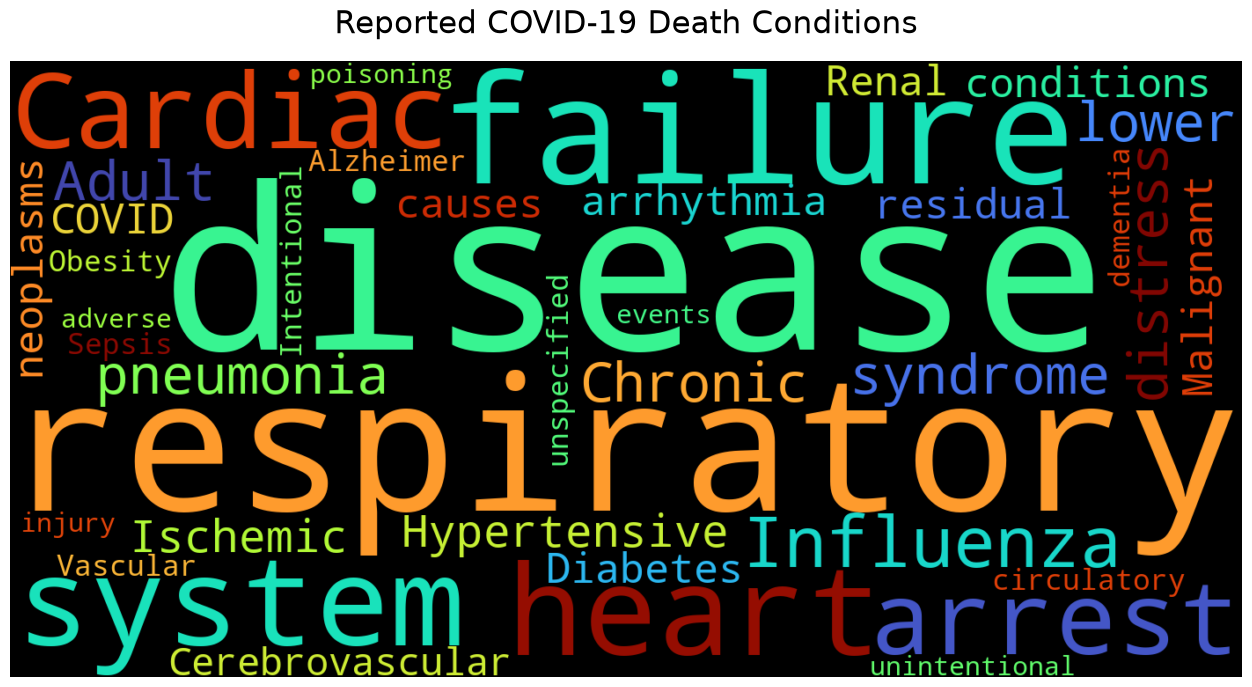

In [96]:
# CONDITION WORD CLOUD

from wordcloud import WordCloud
import matplotlib.pyplot as plt

condition_text = " ".join(
    death_conditions["Condition"]
    .dropna()
    .astype(str)
)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="black",
    colormap="turbo",
    max_words=60,
    collocations=False
).generate(condition_text)

plt.figure(figsize=(16, 8))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Reported COVID-19 Death Conditions",
    fontsize=22,
    pad=20
)

plt.show()

### Key Insight

The condition-level dataset shows that COVID-19 death records are associated with a range of reported underlying conditions.

The frequency distribution highlights which conditions and broader condition groups occur most often within the available records.

These frequencies describe the composition of the provided dataset and should not be interpreted as population-level estimates of mortality risk or as evidence that a condition caused a particular death.

# 16. Final Analytical Findings

The analysis combines country-level, regional, temporal, geographic, and condition-level perspectives to develop an overall view of the COVID-19 dataset.

In [127]:
# FINAL ANALYTICAL SUMMARY

summary_metrics = {
    "Countries Analyzed": covid_clean["Country"].nunique(),

    "Total Reported Cases": covid_clean["TotalCases"].sum(),

    "Total Reported Deaths": covid_clean["TotalDeaths"].sum(),

    "Total Reported Recoveries": covid_clean["TotalRecovered"].sum(),

    "Highest Impact Country": (
        covid_clean
        .dropna(subset=["COVID_Impact_Score"])
        .loc[
            covid_clean["COVID_Impact_Score"].idxmax(),
            "Country"
        ]
    ),

    "Highest Impact Score": (
        covid_clean["COVID_Impact_Score"].max()
    ),

    "Testing-Case Correlation": (
        covid_clean[
            [
                "Calculated_Tests_per_1M",
                "Calculated_Cases_per_1M"
            ]
        ]
        .corr()
        .iloc[0, 1]
    )
}

summary_metrics

{'Countries Analyzed': 209,
 'Total Reported Cases': np.int64(19169166),
 'Total Reported Deaths': np.float64(713007.0),
 'Total Reported Recoveries': np.float64(12070191.0),
 'Highest Impact Country': 'Belgium',
 'Highest Impact Score': np.float64(92.25),
 'Testing-Case Correlation': np.float64(0.3027225969619776)}

In [99]:
# IMPACT CATEGORY SUMMARY

impact_summary = (
    covid_clean[
        covid_clean["Impact_Category"] != "Insufficient Data"
    ]
    ["Impact_Category"]
    .value_counts()
    .reindex(
        [
            "Low",
            "Moderate",
            "High",
            "Critical"
        ],
        fill_value=0
    )
    .reset_index()
)

impact_summary.columns = [
    "Impact Category",
    "Countries"
]

impact_summary

,Impact Category,Countries
0,Low,19
1,Moderate,62
2,High,80
3,Critical,22


In [103]:
# IMPACT CATEGORY PERCENTAGES

impact_summary["Percentage"] = (
    impact_summary["Countries"]
    / impact_summary["Countries"].sum()
    * 100
)

impact_summary["Percentage"] = (
    impact_summary["Percentage"]
    .round(1)
)

impact_summary

,Impact Category,Countries,Percentage
0,Low,19,10.4
1,Moderate,62,33.9
2,High,80,43.7
3,Critical,22,12.0


## Key Findings

### Global Perspective

The temporal analysis shows how reported COVID-19 cases, deaths, recoveries, and active cases evolved throughout the observation period. The animated geographic analysis further demonstrates that reported case burden varied substantially across countries and changed over time.

### Country Impact

The engineered COVID Impact Score provides a standardized analytical framework for comparing countries using case burden, death burden, and active-case burden. Countries with higher scores represent greater relative reported burden within the constructed scoring framework.

### Testing and Case Burden

The testing-versus-case analysis produced a positive correlation of approximately 0.30 between testing intensity and reported cases per million. This indicates a weak-to-moderate positive linear association within the available data, but correlation does not establish causation.

### Regional Differences

The regional analysis demonstrates that COVID-19 case burden and temporal progression differed across WHO regions. Absolute case totals and normalized regional progression provide complementary perspectives on these differences.

### Country-Level Patterns

The country deep-dive analysis demonstrates how confirmed, active, recovered, and death counts evolved together over time, providing a more detailed view of the pandemic within an individual country.

### Reported Death Conditions

The condition-level analysis shows the distribution of reported conditions associated with COVID-19 death records in the supplied dataset. These frequencies describe the composition of the available records and should not be interpreted as causal relationships or population-level mortality estimates.

## Data Limitations

- The analysis is based on reported COVID-19 records contained in the supplied datasets.
- Missing values and differences in reporting practices may affect comparisons between countries and regions.
- The COVID Impact Score is an analytical index created for comparative analysis and is not an official epidemiological measure.
- The testing-versus-case relationship represents correlation within the dataset and should not be interpreted causally.
- Reported case fatality ratios should not be interpreted as true infection fatality rates.
- Condition-level death records describe the supplied dataset and should not be generalized to the wider population without additional epidemiological evidence.
- Geographic visualization uses the official India boundary vector data obtained from the Survey of India for India's territorial representation.

# 17. Conclusion

This project transformed raw COVID-19 datasets into an interactive analytical framework covering data quality, cleaning, feature engineering, country impact assessment, testing relationships, regional comparison, temporal evolution, geographic spread, country-level exploration, and reported death-condition analysis.

The combination of analytical indices and interactive visualizations provides a multidimensional view of the dataset while maintaining clear distinctions between observed patterns, calculated metrics, and causal claims.

The resulting processed dataset and analytical outputs form the foundation for an interactive dashboard that allows users to explore the findings through a more accessible interface.

In [128]:
# EXPORT PROCESSED COVID ANALYTICS DATASET

processed_path = "../data/processed/covid_analysis_ready.csv"

covid_clean.to_csv(
    processed_path,
    index=False
)

print(
    f"Processed dataset exported successfully:\n"
    f"{processed_path}"
)

Processed dataset exported successfully:
../data/processed/covid_analysis_ready.csv


In [129]:
# VERIFY EXPORTED DATASET

processed_check = pd.read_csv(
    processed_path
)

print("Shape:", processed_check.shape)

print("\nColumns:")
print(processed_check.columns.tolist())

print("\nFirst 5 rows:")
display(processed_check.head())

Shape: (209, 25)

Columns:
['Country', 'Continent', 'Population', 'TotalCases', 'TotalDeaths', 'TotalRecovered', 'ActiveCases', 'Serious_Critical', 'Cases_per_1M', 'Deaths_per_1M', 'TotalTests', 'Tests_per_1M', 'WHO Region', 'iso_alpha', 'Mortality_Rate', 'Recovery_Rate', 'Active_Case_Rate', 'Calculated_Cases_per_1M', 'Calculated_Deaths_per_1M', 'Calculated_Tests_per_1M', 'Case_Burden_Score', 'Death_Burden_Score', 'Active_Burden_Score', 'COVID_Impact_Score', 'Impact_Category']

First 5 rows:


,Country,Continent,Population,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,Serious_Critical,Cases_per_1M,Deaths_per_1M,TotalTests,Tests_per_1M,WHO Region,iso_alpha,Mortality_Rate,Recovery_Rate,Active_Case_Rate,Calculated_Cases_per_1M,Calculated_Deaths_per_1M,Calculated_Tests_per_1M,Case_Burden_Score,Death_Burden_Score,Active_Burden_Score,COVID_Impact_Score,Impact_Category
0,USA,North America,3.311981e+08,5032179,162804.0,2576668.0,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas,USA,3.235259,51.203822,45.560919,15193.862961,491.560746,190639.980365,96.153846,95.187166,80.975610,90.77,Critical
1,Brazil,South America,2.127107e+08,2917562,98644.0,2047660.0,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas,BRA,3.381042,70.183941,26.435017,13716.104125,463.747257,62085.210084,94.711538,94.117647,58.048780,82.29,Critical
2,India,Asia,1.381345e+09,2025409,41638.0,1377384.0,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia,IND,2.055782,68.005228,29.938990,1466.258613,30.143085,16034.626432,56.250000,51.871658,66.829268,58.32,High
3,Russia,Europe,1.459409e+08,871894,14606.0,676357.0,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe,RUS,1.675204,77.573306,20.751490,5974.294092,100.081592,203622.850846,85.576923,75.401070,50.731707,70.57,High
4,South Africa,Africa,5.938157e+07,538184,9604.0,387316.0,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa,ZAF,1.784520,71.967208,26.248272,9063.149328,161.733694,53043.515222,91.826923,82.887701,57.073171,77.26,Critical


In [130]:
# FINAL PROCESSED DATA QUALITY CHECK

print("Duplicate rows:", processed_check.duplicated().sum())

print(
    "Missing values:",
    processed_check.isna().sum().sum()
)

print(
    "Countries:",
    processed_check["Country"].nunique()
)

print(
    "Impact categories:",
    processed_check["Impact_Category"].value_counts()
)

Duplicate rows: 0
Missing values: 325
Countries: 209
Impact categories: Impact_Category
High                 80
Moderate             62
Insufficient Data    26
Critical             22
Low                  19
Name: count, dtype: int64


In [131]:
# CREATE DASHBOARD-READY DATASET

dashboard_columns = [
    "Country",
    "Continent",
    "Population",
    "TotalCases",
    "TotalDeaths",
    "TotalRecovered",
    "ActiveCases",
    "TotalTests",
    "Cases_per_1M",
    "Deaths_per_1M",
    "Tests_per_1M",
    "Mortality_Rate",
    "Recovery_Rate",
    "Active_Case_Rate",
    "Calculated_Cases_per_1M",
    "Calculated_Deaths_per_1M",
    "Calculated_Tests_per_1M",
    "Case_Burden_Score",
    "Death_Burden_Score",
    "Active_Burden_Score",
    "COVID_Impact_Score",
    "Impact_Category"
]

dashboard_df = covid_clean[
    dashboard_columns
].copy()

In [132]:
covid_clean.columns.tolist()

['Country',
 'Continent',
 'Population',
 'TotalCases',
 'TotalDeaths',
 'TotalRecovered',
 'ActiveCases',
 'Serious_Critical',
 'Cases_per_1M',
 'Deaths_per_1M',
 'TotalTests',
 'Tests_per_1M',
 'WHO Region',
 'iso_alpha',
 'Mortality_Rate',
 'Recovery_Rate',
 'Active_Case_Rate',
 'Calculated_Cases_per_1M',
 'Calculated_Deaths_per_1M',
 'Calculated_Tests_per_1M',
 'Case_Burden_Score',
 'Death_Burden_Score',
 'Active_Burden_Score',
 'COVID_Impact_Score',
 'Impact_Category']

In [133]:
# EXPORT DASHBOARD-READY DATASET

dashboard_path = (
    "../data/processed/covid_dashboard_ready.csv"
)

dashboard_df.to_csv(
    dashboard_path,
    index=False
)

print(
    f"Dashboard dataset exported successfully:\n"
    f"{dashboard_path}"
)

print(
    f"\nRows: {len(dashboard_df):,}"
)

print(
    f"Columns: {len(dashboard_df.columns)}"
)

Dashboard dataset exported successfully:
../data/processed/covid_dashboard_ready.csv

Rows: 209
Columns: 22
